references
- https://github.com/aws/amazon-sagemaker-examples/tree/main/sagemaker-python-sdk/pytorch_cnn_cifar10
- https://sagemaker.readthedocs.io/en/v2/api/training/estimators.html#sagemaker.estimator.Estimator
- https://sagemaker.readthedocs.io/en/stable/
- https://aws.github.io/deep-learning-containers/reference/available_images/
- https://docs.aws.amazon.com/sagemaker/latest/dg/model-access-training-data.html
- https://docs.aws.amazon.com/sagemaker/latest/dg/model-train-storage.html
- https://docs.aws.amazon.com/sagemaker/latest/dg/model-train-storage-env-var-summary.html

In [70]:
!pip install --upgrade --no-cache-dir "sagemaker<3" pandas numpy matplotlib seaborn scikit-learn "torch==2.6" torchvision sagemaker boto3

INFO: pip is looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 766.7/766.7 MB 188.5 MB/s  0:00:030:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 283.4 MB/s  0:00:01eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 523.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 542.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 1.3 GB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [1]:
import sagemaker

sess = sagemaker.Session()
bucket = sess.default_bucket()
prefix = "sagemaker"

import boto3
import re
from sagemaker import get_execution_role

role = get_execution_role()

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/ec2-user/.config/sagemaker/config.yaml


In [2]:
import pandas as pd
import numpy as np
import torch
import os
import zipfile
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from IPython.display import display
from sagemaker.inputs import TrainingInput
from sagemaker.s3 import S3Uploader

In [56]:
%%bash

curl -L -o ./cifar10.zip https://www.kaggle.com/api/v1/datasets/download/swaroopkml/cifar10-pngs-in-folders
unzip -q cifar10.zip

mkdir dataset
mv cifar10/cifar10/* dataset/

rm cifar10.zip
zip -rq cifar10.zip dataset/

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0   0     0   0     0     0     0  --:--:-- --:--:-- --:--:--     0
100 140.4M 100 140.4M   0     0 11917k     0   0:00:12  0:00:12 --:--:-- 14997k


In [57]:
inputs = S3Uploader.upload("cifar10.zip", "s3://{}/{}".format(bucket, prefix))

In [3]:
test_dataset = datasets.ImageFolder(root='./dataset/test', transform=transforms.ToTensor())
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=True)

print(test_dataset.classes)
print(test_dataset.class_to_idx)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
{'airplane': 0, 'automobile': 1, 'bird': 2, 'cat': 3, 'deer': 4, 'dog': 5, 'frog': 6, 'horse': 7, 'ship': 8, 'truck': 9}


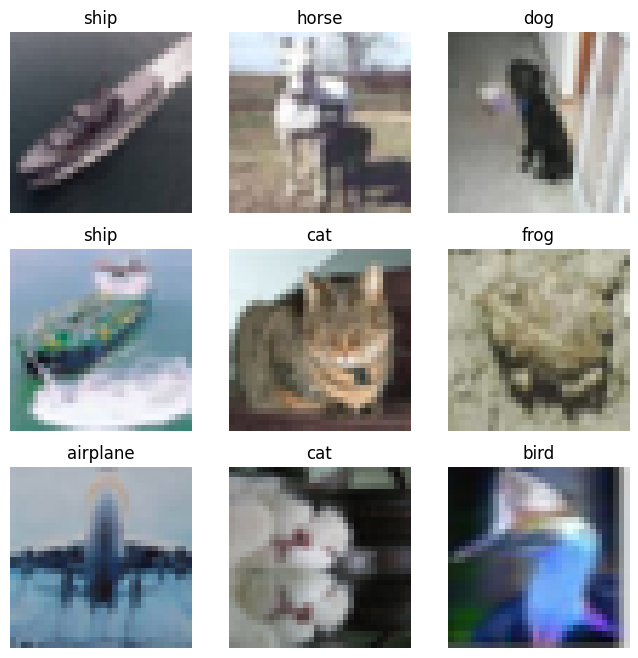

In [4]:
labels = {
  0: 'airplane',
  1: 'automobile',
  2: 'bird',
  3: 'cat',
  4: 'deer',
  5: 'dog',
  6: 'frog',
  7: 'horse',
  8: 'ship',
  9: 'truck'
}

pre = datasets.ImageFolder(root='./dataset/train', transform=transforms.ToTensor())

figure = plt.figure(figsize=(8, 8))
for i in range(1, 10):
  idx = torch.randint(len(pre), size=(1, )).item()
  img, label = pre[idx]
  figure.add_subplot(3, 3, i)
  plt.title(labels[label])
  plt.axis('off')
  plt.imshow(img.permute(1, 2, 0))

plt.show()

In [ ]:
from sagemaker.pytorch import PyTorch

estimator = PyTorch(
    entry_point="cnn_sagemaker_cifar10_train.py",
    framework_version="2.6",
    py_version="py312",
    instance_type="ml.g4dn.xlarge",
    instance_count=1,
    output_path="s3://{}/{}/output/".format(bucket, prefix),
    checkpoint_s3_uri="s3://{}/{}/checkpoint/".format(bucket, prefix),
    role=role
)

estimator.fit({
    "train": TrainingInput("s3://{}/{}/cifar10.zip".format(bucket, prefix)),  # /opt/ml/input/data/train
})

INFO:sagemaker.telemetry.telemetry_logging:SageMaker Python SDK will collect telemetry to help us better understand our user's needs, diagnose issues, and deliver additional features.
To opt out of telemetry, please disable via TelemetryOptOut parameter in SDK defaults config. For more information, refer to https://sagemaker.readthedocs.io/en/stable/overview.html#configuring-and-using-defaults-with-the-sagemaker-python-sdk.
INFO:sagemaker.image_uris:image_uri is not presented, retrieving image_uri based on instance_type, framework etc.
INFO:sagemaker.image_uris:image_uri is not presented, retrieving image_uri based on instance_type, framework etc.
INFO:sagemaker:Creating training-job with name: pytorch-training-2026-06-17-11-37-04-451


2026-06-17 11:37:04 Starting - Starting the training job...
2026-06-17 11:37:38 Pending - Preparing the instances for training...
2026-06-17 11:38:00 Downloading - Downloading input data...
2026-06-17 11:38:25 Downloading - Downloading the training image........................
2026-06-17 11:42:28 Training - Training image download completed. Training in progress..bash: cannot set terminal process group (-1): Inappropriate ioctl for device
bash: no job control in this shell
CUDA compat package should be installed for NVIDIA driver smaller than 560.35.05
Current installed NVIDIA driver version is 570.211.01
Skipping CUDA compat setup as newer NVIDIA driver is installed
2026-06-17 11:42:43,233 sagemaker-training-toolkit INFO     Imported framework sagemaker_pytorch_container.training
2026-06-17 11:42:43,252 sagemaker-training-toolkit INFO     No Neurons detected (normal if no neurons installed)
2026-06-17 11:42:43,263 sagemaker_pytorch_container.training INFO     Block until all host DNS

references
- https://docs.aws.amazon.com/sagemaker/latest/dg/neo-deployment-hosting-services-sdk.html

In [9]:
predictor = estimator.deploy(initial_instance_count=1, instance_type="ml.g4dn.xlarge")

INFO:sagemaker:Repacking model artifact (s3://sagemaker-ap-southeast-2-200148130345/sagemaker/output/pytorch-training-2026-06-17-11-02-19-667/output/model.tar.gz), script artifact (s3://sagemaker-ap-southeast-2-200148130345/pytorch-training-2026-06-17-11-02-19-667/source/sourcedir.tar.gz), and dependencies ([]) into single tar.gz file located at s3://sagemaker-ap-southeast-2-200148130345/pytorch-training-2026-06-17-11-20-16-151/model.tar.gz. This may take some time depending on model size...
INFO:sagemaker:Creating model with name: pytorch-training-2026-06-17-11-20-16-151
INFO:sagemaker:Creating endpoint-config with name pytorch-training-2026-06-17-11-20-16-151
INFO:sagemaker:Creating endpoint with name pytorch-training-2026-06-17-11-20-16-151


---------!

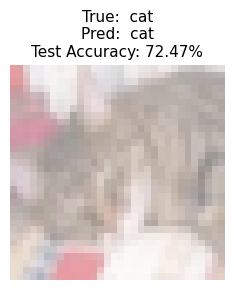

In [18]:
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

idx = torch.randint(len(test_dataset), (1,)).item()
image, label = test_dataset[idx]

output = predictor.predict(image.unsqueeze(0).numpy())
predicted = torch.max(torch.from_numpy(np.array(output)), 1)[1].item()

correct, total = 0, 0
for images, labels in test_loader:
    outputs = predictor.predict(images.numpy())
    preds = torch.max(torch.from_numpy(np.array(outputs)), 1)[1]
    correct += (preds == labels).sum().item()
    total += labels.size(0)
accuracy = 100 * correct / total

img = image * 0.5 + 0.5
plt.figure(figsize=(3, 3))
plt.imshow(img.permute(1, 2, 0).numpy())
plt.axis(False)
plt.title(
    f"True:  {classes[label]}\n"
    f"Pred:  {classes[predicted]}\n"
    f"Test Accuracy: {accuracy:.2f}%",
    fontsize=11
)
plt.tight_layout()
plt.show()